# Лабораторная работа 1. Основы PyTorch и обучение полносвязной нейронной сети

В данной работе реализуется полносвязная нейронная сеть для классификации табличных данных на датасете F1 (результаты гонок Формулы 1).

**Задача классификации:** предсказание команды-победителя (team) по признакам гонки.

## 1. Подготовка данных

### 1.1 Загрузка датасета

In [53]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# Загрузка датасета F1
df = pd.read_csv('f1_dataset.csv')
df.head()

,date,continent,grand_prix,circuit,winner_name,team,time,laps,year
0,1950-05-13,Europe,Great Britain,Silverstone Circuit,Nino Farina,Alfa Romeo,02:13:23,70.0,1950
1,1950-05-21,Europe,Monaco,Circuit de Monaco,Juan Manuel Fangio,Alfa Romeo,03:13:18,100.0,1950
2,1950-05-30,North America,United States,Indianapolis Motor Speedway,Johnnie Parsons,Kurtis Kraft Offenhauser,02:46:55,138.0,1950
3,1950-06-04,Europe,Switzerland,Circuit Bremgarten,Nino Farina,Alfa Romeo,02:02:53,42.0,1950
4,1950-06-18,Europe,Belgium,Circuit de Spa Francorchamps,Juan Manuel Fangio,Alfa Romeo,02:47:26,35.0,1950


In [54]:
# Базовая информация о датасете
print(f"Размер датасета: {df.shape}")
print(f"\nКоличество уникальных команд: {df['team'].nunique()}")
print(f"\nРаспределение по командам (топ-15):")
df['team'].value_counts().head(15)

Размер датасета: (1142, 9)

Количество уникальных команд: 65

Распределение по командам (топ-15):


,count
team,
Ferrari,249
Mercedes,121
McLaren Mercedes,85
Williams Renault,64
Lotus Ford,47
McLaren Honda,44
Red Bull Racing Renault,35
McLaren Ford,35
Renault,35


Для задачи классификации возьмём топ-10 команд по частоте появления, чтобы избежать слишком редких классов:

In [55]:
# Оставляем только топ-N команд для стабильной классификации
TOP_TEAMS = 10
top_teams = df['team'].value_counts().head(TOP_TEAMS).index.tolist()
df_filtered = df[df['team'].isin(top_teams)].copy()
print(f"Размер после фильтрации: {df_filtered.shape}")
print(f"Классы: {top_teams}")

Размер после фильтрации: (745, 9)
Классы: ['Ferrari', 'Mercedes', 'McLaren Mercedes', 'Williams Renault', 'Lotus Ford', 'McLaren Honda', 'Red Bull Racing Renault', 'McLaren Ford', 'Renault', 'Red Bull Racing Honda RBPT']


In [56]:
# Подготовка признаков и целевой переменной
# Расширенный набор признаков для лучшего предсказания команды-победителя:

df_filtered['date'] = pd.to_datetime(df_filtered['date'], errors='coerce')
df_filtered['month'] = df_filtered['date'].dt.month

# Преобразование времени гонки (HH:MM:SS) в секунды
def time_to_seconds(t):
    if pd.isna(t):
        return np.nan
    parts = str(t).split(':')
    if len(parts) == 3:
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
    return np.nan

df_filtered['time_seconds'] = df_filtered['time'].apply(time_to_seconds)

# Кодирование категориальных признаков (circuit и grand_prix сильно связаны с победителем)
le_continent = LabelEncoder()
le_circuit = LabelEncoder()
le_grand_prix = LabelEncoder()

df_filtered['continent_encoded'] = le_continent.fit_transform(df_filtered['continent'].astype(str))
df_filtered['circuit_encoded'] = le_circuit.fit_transform(df_filtered['circuit'].astype(str))
df_filtered['grand_prix_encoded'] = le_grand_prix.fit_transform(df_filtered['grand_prix'].astype(str))

df_filtered = df_filtered.dropna(subset=['laps', 'month', 'time_seconds'])

# Целевая переменная - команда
le_team = LabelEncoder()
y = le_team.fit_transform(df_filtered['team'])

# Признаки: year, laps, month, continent, circuit, grand_prix, время гонки в секундах
X = df_filtered[['year', 'laps', 'month', 'continent_encoded', 'circuit_encoded',
                 'grand_prix_encoded', 'time_seconds']].values.astype(np.float32)

print(f"Признаки: year, laps, month, continent, circuit, grand_prix, time_seconds")
print(f"Число признаков: {X.shape[1]}")
print(f"Число классов: {len(le_team.classes_)}")
print(f"Размерность X: {X.shape}, y: {y.shape}")

Признаки: year, laps, month, continent, circuit, grand_prix, time_seconds
Число признаков: 7
Число классов: 10
Размерность X: (745, 7), y: (745,)


### 1.2 Разделение данных

In [57]:
# Разделение на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")

Обучающая выборка: 596 образцов
Тестовая выборка: 149 образцов


### 1.3 Нормализация признаков

In [58]:
# Стандартизация с помощью StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 1.4 Преобразование в тензоры PyTorch

In [59]:
# Преобразование в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test)

print(f"X_train_tensor: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}")
print(f"y_train_tensor: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}")

X_train_tensor: torch.Size([596, 7]), dtype: torch.float32
y_train_tensor: torch.Size([596]), dtype: torch.int64


## 2. Создание нейронной сети

### 2.1 Архитектура сети

In [60]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [61]:
# Параметры сети
input_size = X_train.shape[1]
hidden_size = 64  # количество нейронов в скрытом слое
num_classes = len(le_team.classes_)

model = NeuralNetwork(input_size, hidden_size, num_classes)
print(model)

NeuralNetwork(
  (fc1): Linear(in_features=7, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


### 2.2 Функция потерь и оптимизатор

In [62]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 3. Обучение модели

### 3.1 Цикл обучения

In [63]:
num_epochs = 100
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

In [64]:
for epoch in range(num_epochs):
    model.train()

    # Обнуление градиентов
    optimizer.zero_grad()

    # Прямой проход
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Обратное распространение и обновление весов
    loss.backward()
    optimizer.step()

    # Метрики на обучающей выборке
    with torch.no_grad():
        _, predicted = torch.max(outputs, 1)
        train_acc = (predicted == y_train_tensor).float().mean().item()

    train_losses.append(loss.item())
    train_accuracies.append(train_acc)

    # Метрики на тестовой выборке (без градиентов)
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor).item()
        _, test_predicted = torch.max(test_outputs, 1)
        test_acc = (test_predicted == y_test_tensor).float().mean().item()

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Эпоха [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Эпоха [10/100], Train Loss: 2.2504, Train Acc: 0.1393, Test Loss: 2.2391, Test Acc: 0.1141
Эпоха [20/100], Train Loss: 2.1268, Train Acc: 0.3238, Test Loss: 2.1276, Test Acc: 0.3020
Эпоха [30/100], Train Loss: 2.0285, Train Acc: 0.3456, Test Loss: 2.0418, Test Acc: 0.3356
Эпоха [40/100], Train Loss: 1.9525, Train Acc: 0.3456, Test Loss: 1.9792, Test Acc: 0.3490
Эпоха [50/100], Train Loss: 1.8936, Train Acc: 0.3540, Test Loss: 1.9342, Test Acc: 0.3557
Эпоха [60/100], Train Loss: 1.8451, Train Acc: 0.3674, Test Loss: 1.8992, Test Acc: 0.3691
Эпоха [70/100], Train Loss: 1.8023, Train Acc: 0.3742, Test Loss: 1.8689, Test Acc: 0.4094
Эпоха [80/100], Train Loss: 1.7630, Train Acc: 0.3876, Test Loss: 1.8412, Test Acc: 0.4094
Эпоха [90/100], Train Loss: 1.7266, Train Acc: 0.4010, Test Loss: 1.8153, Test Acc: 0.4362
Эпоха [100/100], Train Loss: 1.6926, Train Acc: 0.4111, Test Loss: 1.7909, Test Acc: 0.4430


### 3.2 Визуализация результатов

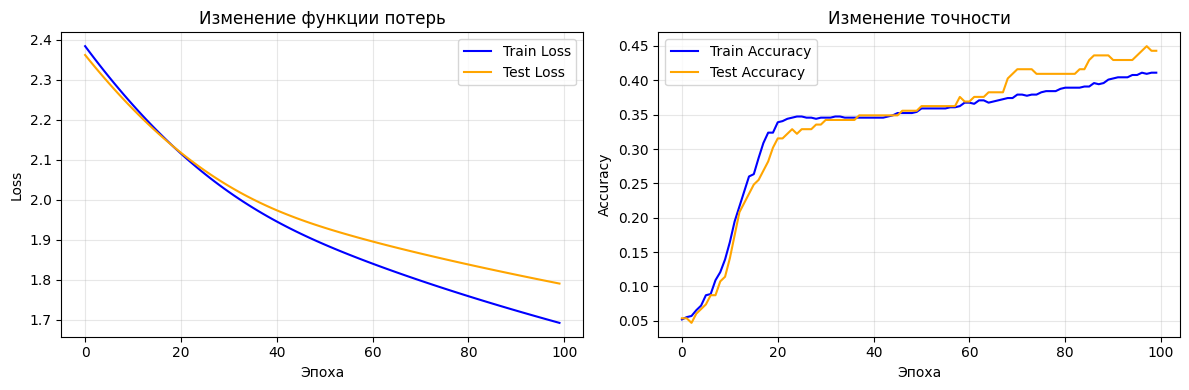

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График функции потерь
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(test_losses, label='Test Loss', color='orange')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.set_title('Изменение функции потерь')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График точности
ax2.plot(train_accuracies, label='Train Accuracy', color='blue')
ax2.plot(test_accuracies, label='Test Accuracy', color='orange')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.set_title('Изменение точности')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Финальные метрики

In [66]:
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_tensor)
    y_pred_train_labels = torch.argmax(y_pred_train, dim=1).numpy()
    y_pred_test = model(X_test_tensor)
    y_pred_test_labels = torch.argmax(y_pred_test, dim=1).numpy()

train_accuracy = accuracy_score(y_train, y_pred_train_labels)
test_accuracy = accuracy_score(y_test, y_pred_test_labels)
train_f1 = f1_score(y_train, y_pred_train_labels, average='weighted')
test_f1 = f1_score(y_test, y_pred_test_labels, average='weighted')

print("Метрики нейронной сети:")
print(f"  Обучающая выборка - Accuracy: {train_accuracy:.4f}, F1-score: {train_f1:.4f}")
print(f"  Тестовая выборка  - Accuracy: {test_accuracy:.4f}, F1-score: {test_f1:.4f}")

Метрики нейронной сети:
  Обучающая выборка - Accuracy: 0.4144, F1-score: 0.2757
  Тестовая выборка  - Accuracy: 0.4430, F1-score: 0.2971


In [67]:
# быстрое сравнение с логистической регрессией на тех же данных
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print(f"Логистическая регрессия - Accuracy: {lr_acc:.4f}, F1: {lr_f1:.4f}")
print(f"Нейронная сеть         - Accuracy: {test_accuracy:.4f}, F1: {test_f1:.4f}")

Логистическая регрессия - Accuracy: 0.4631, F1: 0.3438
Нейронная сеть         - Accuracy: 0.4430, F1: 0.2971
